<h3> NCVS Data Analysis and Police Reporting Prediction </h3>

Part II: Household Victimization Analysis and Police Reporting Prediction

<span> Dataset: NCVS Household Victimization 1993-2019.csv </span> </br>
<span> Link: https://www.bjs.gov/developer/ncvs/data/csv/NCVS_HOUSEHOLD_1993-2019.zip </span>

<b> Notebook by: Uttej Kumar Reddy Gade </b> </br> 
<b> SJSU ID: 016065543 </b>

In [149]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.model_selection import train_test_split
# Regression 
from sklearn.linear_model import LinearRegression, LogisticRegression
# Classification 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Clustering
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
# Neural Networks
from sklearn.neural_network import MLPClassifier

# Performance Metrics
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# Principal Component Analysis
from sklearn.decomposition import PCA

<h1> Dataset </h1>

In [2]:
df = pd.read_csv('NCVS_HOUSEHOLD_VICTIMIZATION_1993-2019.csv')

In [3]:
df.head()

,year,weight,msa,hincome,hhage,hhgen,hhhisp,hhrace1r,hheth1r,hnumber,popsize,region,notify,newcrime,newoff,vicservices,locationr
0,1993,3219.62735,3,1,3,1,2,1,1,1,NaN,-1,2,3,8,2.0,1
1,1993,3219.62735,3,1,3,1,2,1,1,1,NaN,-1,2,3,8,2.0,1
2,1993,3219.62735,3,1,3,1,2,1,1,1,NaN,-1,2,3,8,2.0,1
3,1993,2999.05015,3,4,2,1,2,1,1,3,NaN,-1,1,3,8,2.0,1
4,1993,2999.05015,3,4,3,2,2,1,1,1,NaN,-1,2,3,8,2.0,1


In [4]:
df.shape

(216269, 17)

In [5]:
df.describe()

,year,weight,msa,hincome,hhage,hhgen,hhhisp,hhrace1r,hheth1r,hnumber,popsize,region,notify,newcrime,newoff,vicservices,locationr
count,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,177437.000000,216269.000000,216269.000000,216269.0,216269.000000,214994.000000,216269.000000
mean,2004.462822,2539.211250,1.731039,18.443323,3.115338,1.466673,2.208430,1.233825,1.603646,2.206262,1.598133,2.109322,1.661306,3.0,7.584027,1.983279,1.910343
std,8.361142,1954.156798,0.684604,31.214778,0.995070,0.498889,5.383467,0.532468,1.048591,0.819708,1.482455,1.714463,0.537349,0.0,0.781140,0.128226,1.272344
min,1993.000000,33.798650,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-1.000000,1.000000,3.0,6.000000,1.000000,1.000000
25%,1997.000000,1955.989810,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,3.0,8.000000,2.000000,1.000000
50%,2003.000000,2248.094720,2.000000,5.000000,3.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,3.000000,2.000000,3.0,8.000000,2.000000,1.000000
75%,2012.000000,2812.389420,2.000000,7.000000,4.000000,2.000000,2.000000,1.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.0,8.000000,2.000000,3.000000
max,2019.000000,79767.074400,3.000000,88.000000,5.000000,2.000000,88.000000,3.000000,4.000000,4.000000,5.000000,4.000000,8.000000,3.0,8.000000,2.000000,5.000000


popsize and vicservices have some missing values

In [6]:
# Find out the number of missing values for popsize and vicservices
df.isnull().sum()

year               0
weight             0
msa                0
hincome            0
hhage              0
hhgen              0
hhhisp             0
hhrace1r           0
hheth1r            0
hnumber            0
popsize        38832
region             0
notify             0
newcrime           0
newoff             0
vicservices     1275
locationr          0
dtype: int64

<b> ------------------------------ OBSERVATION ------------------------------ </b>  
A significant number of rows have 'popsize' as null (17%)  
Rows with empty 'vicservices' contribute for 0.6% of the total data

<h1> Exploratory Data Analysis </h1>

<b>1. What is the number of victimizations per year? </b>

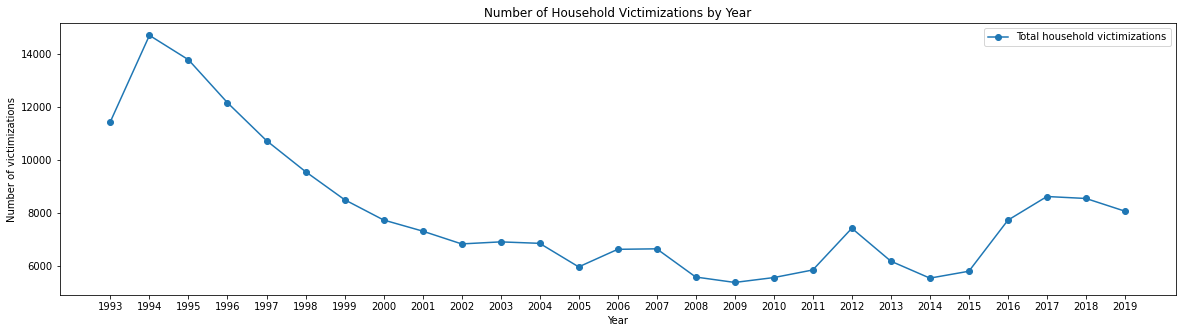

In [127]:
dfVicPerYear = df.groupby(['year']).size()

figVicPerYear = plt.figure()

axVicPerYear = plt.axes()
axVicPerYear.set_xlabel('Year')
axVicPerYear.set_ylabel('Number of victimizations')
axVicPerYear.set_title('Number of Household Victimizations by Year')

years = []
vicCounts = []
for year, vicCount in dfVicPerYear.groupby(level = 'year'):
  years.append(year)
  vicCounts.append(vicCount)

plt.plot(years, vicCounts, marker='o', label = 'Total household victimizations')
axVicPerYear.legend()

plt.xticks(years)
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]
plt.rcParams["figure.figsize"] = (20, 5)

plt.show()

In [8]:
figVicPerYear.savefig('01-number_of_household_victimizations_by_year.pdf', bbox_inches='tight')

<b>2. What are the reporting status (Notified, Not notified, Do not know, Unknown) counts through the Years</b>

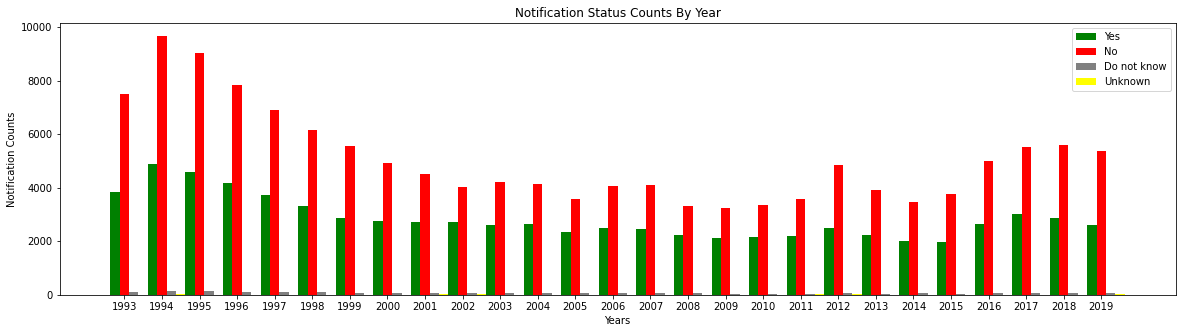

In [9]:
dfVicByNotifyPerYear = df.groupby(['year', 'notify']).size()

"""
[
  {
    year: 0,
    1: 0, # Yes
    2: 0, # No
    3: 0, # Do not know
    8: 0, # Unknown
  },
]
"""
notifyStatusPerYear = []

years = []

# Construct notifyStatusPerYear array of dictionaries 
for year, reporting in dfVicByNotifyPerYear.groupby(level = 'year'):
  years.append(year)
  
  notifyInfo = {}
  notifyInfo['year'] = year

  for i in range(len(reporting.keys())):
    notifyStatus = reporting.keys()[i][1]
    notifyStatusVal = reporting.values[i]
    notifyInfo[notifyStatus] = notifyStatusVal
  
  notifyStatusPerYear.append(notifyInfo)

# Function to get notification statuses in an array
def getStatusCounts (notifyStatus):
  notifyStatusCounts = []
  for x in notifyStatusPerYear:
    notifyStatusCounts.append(x[notifyStatus])
  return notifyStatusCounts

# Plot bar graphs
figVicByNotifyPerYear, axVicByNotifyPerYear = plt.subplots()

pltStartingIndex = np.arange(len(years))
width = 0.25

notifyYesCounts = getStatusCounts(1) # 1 = Yes
bar1 = plt.bar(pltStartingIndex, notifyYesCounts, width, color = 'green')

notifyNoCounts = getStatusCounts(2) # 2 = No
bar2 = plt.bar(pltStartingIndex + width, notifyNoCounts, width, color = 'red')

notifyDoNotKnowCounts = getStatusCounts(3) # 3 = Do not know
bar3 = plt.bar(pltStartingIndex + width * 2, notifyDoNotKnowCounts, width, color = 'grey')

notifyUnknownCounts = getStatusCounts(8) # 8 = Unknown
bar4 = plt.bar(pltStartingIndex + width * 3, notifyUnknownCounts, width, color = 'yellow')

plt.xlabel('Years')
plt.ylabel('Notification Counts')
plt.title('Notification Status Counts By Year')

plt.xticks(pltStartingIndex + width, years)
plt.legend( (bar1, bar2, bar3, bar4), ('Yes', 'No', 'Do not know', 'Unknown') )

plt.show()

<b> ------------------------------ OBSERVATION ------------------------------ </b>  
From 1993-2019, the number of unnotified crimes has been consistently and  
significantly higher than notified crimes

In [10]:
figVicByNotifyPerYear.savefig('02-notification_status_counts_by_year.pdf', bbox_inches='tight')

<b>3. By what percentage are the un-notified victimisations higher than the notified through the years? </b>

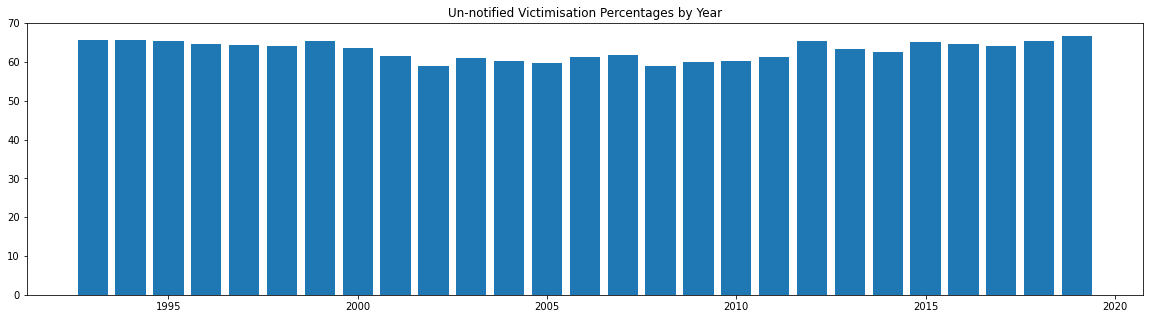

In [11]:
def getPercentageOfUnnotifiedVictimisation (year):
  for x in notifyStatusPerYear:
    if (x['year'] == year):
      return (x[2] / (x[1] + x[2] + x[3] + x[8])) * 100

percentageOfUnnotifiedVictimisationsByYear = []
for year in years:
  percentageOfUnnotifiedVictimisationsByYear.append(getPercentageOfUnnotifiedVictimisation(year))

figUnnotifiedPercentagePerYear = plt.figure()

plt.bar(years, percentageOfUnnotifiedVictimisationsByYear)
plt.title('Un-notified Victimisation Percentages by Year')

plt.show()

<b> ------------------------------ OBSERVATION ------------------------------ </b>  
Unnotified victimizations make up around 60% of the total victimizations in every year

In [12]:
figUnnotifiedPercentagePerYear.savefig('03-unnotified-victimisation-percentages-by-year.pdf', bbox_inches='tight')

<b>4. What type of crimes are most likely to be reported? </b>  
<b>Similarly, what type of crimes are most likely to go unnotified? </b>

In [ ]:
dfNotifyNo = df[df['notify'] == 2]
dfNotifyNoByNewoff = dfNotifyNo.groupby('newoff').size()

dfNotifyYes = df[df['notify'] == 1]
dfNotifYesByNewoff = dfNotifyYes.groupby('newoff').size()

notifNoNewoffCounts = dfNotifyNoByNewoff.values
notifYesNewoffCounts = dfNotifYesByNewoff.values

newoff = dfNotifyNoByNewoff.keys()
newoffLabels = []
for i in range(len(newoff)):
    if (newoff[i] == 6):
        newoffLabels.append('Burglary/ Trespassing')
    elif (newoff[i] == 7):
        newoffLabels.append('Motor Vehicle Theft')
    elif (newoff[i] == 8):
        newoffLabels.append('Theft')

figReportingStatusByCrime, (ax1ReportingStatusByCrime, ax2ReportingStatusByCrime) = plt.subplots(1, 2, figsize = (10, 10))
figReportingStatusByCrime.tight_layout(pad=5.0)

ax1ReportingStatusByCrime.pie(notifNoNewoffCounts, labels = newoffLabels, autopct = '%1.2f%%')
ax1ReportingStatusByCrime.set_title('Unnotified offenses composition')

ax2ReportingStatusByCrime.pie(notifYesNewoffCounts, labels = newoffLabels, autopct = '%1.2f%%')
ax2ReportingStatusByCrime.set_title('Notified offenses composition')

plt.show()

<h1> Data Pre-processing </h1>

In [13]:
dfPreprocessed = df.copy()

<h3> 1. Handle empty popsize values (38832/216269) </h3>  
We can reasonably assume that msa and popsize have a direct co-relation  </br>
Missing popsize values can be filled with the median of popsize values for their corresponding MSAs

In [14]:
dfNotNullPop = df[-df['popsize'].isnull()]

dfNotNullPopMSA1 = dfNotNullPop[dfNotNullPop['msa'] == 1]
medianMSA1 = dfNotNullPopMSA1['popsize'].median()

dfNotNullPopMSA2 = dfNotNullPop[dfNotNullPop['msa'] == 2]
medianMSA2 = dfNotNullPopMSA2['popsize'].median()

dfNotNullPopMSA3 = dfNotNullPop[dfNotNullPop['msa'] == 3]
medianMSA3 = dfNotNullPopMSA3['popsize'].median()

for index, row in df[df['popsize'].isnull()].iterrows():
  if (row['msa'] == 1):
    dfPreprocessed.at[index, 'popsize'] = medianMSA1
  if (row['msa'] == 2):
    dfPreprocessed.at[index, 'popsize'] = medianMSA2
  if (row['msa'] == 3):
    dfPreprocessed.at[index, 'popsize'] = medianMSA3

<h3> 2. Handle empty vicservices values (1275/216269)</h3>  
As vicservices make up for a small percentage of the total rows and, </br>as there is no accurate way of determining whether a particular victimisation received victim services,  </br>
the rows with empty vicservices values can be removed </br>

In [15]:
print ('Number of rows before dropping: ' + str(dfPreprocessed.shape[0]))

dfPreprocessed.dropna(subset=['vicservices'], inplace = True)

print ('Number of rows after dropping: ' + str(dfPreprocessed.shape[0]))

Number of rows before dropping: 216269
Number of rows after dropping: 214994


<h3> 3. Remove outliers </h3>

We are interested in predicting given certain characteristics of a victimisation,  </br>
if it is likely to be reported to the police or not. </br>
The 'notify' column however contains two more values, 'Do not know' (3) and Unknown (8)

In [16]:
dfPreprocessed['notify'].value_counts()

2    136972
1     76119
3      1877
8        26
Name: notify, dtype: int64

As these values (3 and 8) make up for a very small percentage of the total data,  
these rows can be considered as outliers and dropped.

In [17]:
print ('Number of rows before dropping: ' + str(dfPreprocessed.shape[0]))

dfPreprocessed = dfPreprocessed[dfPreprocessed.notify.isin([3, 8]) == False]

print ('Number of rows after dropping: ' + str(dfPreprocessed.shape[0]))

Number of rows before dropping: 214994
Number of rows after dropping: 213091


<h3> 3. Remove unnecessary columns with regards to prediction </h3>
Drop weight column

In [18]:
dfPreprocessed.drop('weight', inplace=True, axis=1)

Check corelations of other columns with notify

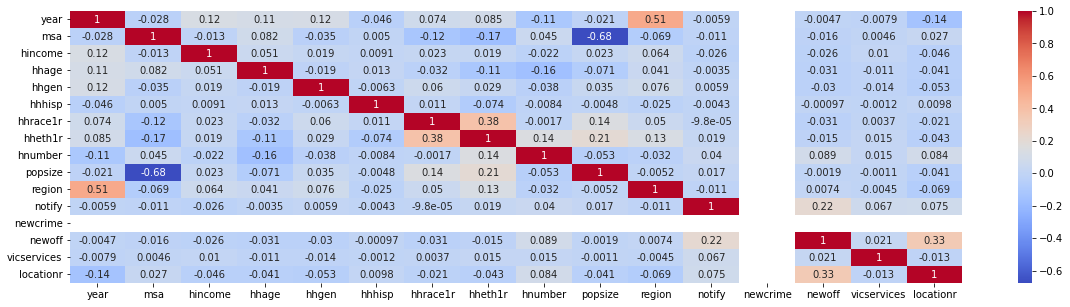

In [19]:
plt.rcParams["figure.figsize"] = (20, 5)
figHeatmap = sns.heatmap(dfPreprocessed.corr(), annot = True, cmap='coolwarm')

'newcrime' has no corelation with 'notify'. So it can be dropped.  
All the columns have a significant corelation with 'notify' and hence, should not be removed

In [20]:
dfPreprocessed.drop('newcrime', inplace=True, axis=1)

<h3> 4. One-hot encode categorical variables </h3>
All the columns are categorical, and hence for the models to give equal importance </br>
to their values, they need to be one-hot encoded

In [21]:
print ('Shape before one-hot encoding: ' + str(dfPreprocessed.shape))

dfEncoded = pd.get_dummies(data = dfPreprocessed, columns = [
  'year',
  'msa',
  'hincome',
  'hhage',
  'hhgen',
  'hhhisp',
  'hhrace1r',
  'hheth1r',
  'hnumber',
  'popsize',
  'region',
  'newoff',
  'vicservices',
  'locationr'
  ])

print ('Shape after one-hot encoding: ' + str(dfEncoded.shape))


Shape before one-hot encoding: (213091, 15)
Shape after one-hot encoding: (213091, 81)


In [22]:
dfEncoded.head()

,notify,year_1993,year_1994,year_1995,year_1996,year_1997,year_1998,year_1999,year_2000,year_2001,...,newoff_6,newoff_7,newoff_8,vicservices_1.0,vicservices_2.0,locationr_1,locationr_2,locationr_3,locationr_4,locationr_5
0,2,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
1,2,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
2,2,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
4,2,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0


Replace '2' with '0' in 'notify' column so as to make it consistent with other columns format, which is now binary  
So now, instead of '2', '0' means No or Unnotified victimisation

In [23]:
dfEncoded.notify.replace(2, 0, inplace=True) 

In [24]:
dfEncoded.head()

,notify,year_1993,year_1994,year_1995,year_1996,year_1997,year_1998,year_1999,year_2000,year_2001,...,newoff_6,newoff_7,newoff_8,vicservices_1.0,vicservices_2.0,locationr_1,locationr_2,locationr_3,locationr_4,locationr_5
0,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0


<h1> Train Models </h1>

In [67]:
def performanceMetrics(test_y, pred_y, label, printMetrics = False):
  score_accuracy = accuracy_score(test_y, pred_y)
  score_recall = recall_score(test_y, pred_y)
  score_precision = precision_score(test_y, pred_y)
  score_f1 = f1_score(test_y, pred_y)

  if (printMetrics):
    print('accuracy_score: %.3f' % score_accuracy)
    print('Recall: %.3f' % score_recall)
    print('Precision: %.3f' % score_precision)
    print('F1 Score: %.3f' % score_f1)

  return label, score_accuracy, score_recall, score_precision, score_f1, pred_y

In [79]:
def printConfusionMatrix(validate_Y, pred_Y, label):
  confusionMatrix = confusion_matrix(y_true = validate_Y, y_pred = pred_Y)

  index = ['Actual No', 'Actual Yes']
  columns = ['Predicted No', 'Predicted Yes']
  
  dfConfusionMatrix = pd.DataFrame(data = confusionMatrix, columns = columns, index = index)
  sns.heatmap(dfConfusionMatrix, annot=True, fmt='d', cmap='YlGnBu')

  plt.title('Confusion Matrix - ' + label)
  plt.show()

<h3> Linear Regression </h3>

In [78]:
def modelLinearRegression(train_X, test_X, train_y, test_y, label, printMetrics = False):
  lr = LinearRegression(n_jobs = -1) # Use all available cores
  model = lr.fit(train_X, train_y)
  pred_y = model.predict(test_X)
  
  # As the target variable is binary in nature, we set a threshold
  # and convert pred_y values to binary based around that

  THRESHOLD = 0.5
  pred_y = [1 if x > THRESHOLD else 0 for x in pred_y]

  return performanceMetrics(test_y, pred_y, label, printMetrics)
  

<h3> Logistic Regression </h3>

In [70]:
def modelLogisticRegression(train_X, test_X, train_y, test_y, label, printMetrics = False):
  logmodel = LogisticRegression(random_state = RANDOM_STATE, n_jobs = -1) # Use all available cores
  model = logmodel.fit(train_X, train_y)
  pred_y = model.predict(test_X)

  return performanceMetrics(test_y, pred_y, label, printMetrics)

<h3> Decision Trees </h3>

In [71]:
def modelDecisionTree(train_X, test_X, train_y, test_y, label, printMetrics = False):
  dtc = DecisionTreeClassifier(random_state = RANDOM_STATE)
  dtc.fit(train_X, train_y)
  pred_y = dtc.predict(X_validate)

  return performanceMetrics(test_y, pred_y, label, printMetrics)

<h3> Random Forest </h3>

In [72]:
def modelRandomForest(train_X, test_X, train_y, test_y, label, printMetrics = False):
  rfc = RandomForestClassifier(n_jobs = -1, random_state = RANDOM_STATE)
  rfc.fit(train_X, train_y)
  pred_y = rfc.predict(test_X)

  return performanceMetrics(test_y, pred_y, label, printMetrics)

<h3> K Nearest Neighbours </h3>

In [188]:
def modelKNN(train_X, test_X, train_y, test_y, label, printMetrics = False):
  n_neighbors = len(np.unique(train_y)) + 1 # Choosing odd number of neighbours (3) nearest to number of classes, 2
  knn = KNeighborsClassifier(n_neighbors = 3) 
  knn.fit(train_X, train_y)
  pred_y = knn.predict(test_X)

  return performanceMetrics(test_y, pred_y, label, printMetrics)

<h3>K-Means Clustering with SVM for classification</h3>

In [74]:
def modelKMeans(train_X, test_X, train_y, test_y, label, printMetrics = False):
  n_clusters = len(np.unique(train_y)) # 2 (0 and 1). So 2 clusters is the target.
  clf = KMeans(n_clusters = n_clusters, random_state = RANDOM_STATE)
  clf.fit(train_X)
  
  y_labels_train = clf.labels_
  y_labels_test = clf.predict(test_X)

  train_X['km_clust'] = y_labels_train
  test_X['km_clust'] = y_labels_test

  model = SVC()
  model.fit(train_X, train_y)
  pred_y = model.predict(test_X)
  
  return performanceMetrics(test_y, pred_y, label, printMetrics)

<h3> Neural Network </h3>

In [75]:
def modelNeuralNetwork(train_X, test_X, train_y, test_y, label, printMetrics = False):
  mlp = MLPClassifier(random_state = RANDOM_STATE, verbose=False)
  mlp.fit(train_X, train_y)
  pred_y = mlp.predict(test_X)

  return performanceMetrics(test_y, pred_y, label, printMetrics)

<h1> Model Evaluation - I</h1>

In [ ]:
RANDOM_STATE = 2022

dfPrediction = dfEncoded.copy()
Y_sample = dfPrediction['notify']
X_sample = dfPrediction.drop('notify', axis=1)

X_train, X_validate, y_train, y_validate = train_test_split(X_sample, Y_sample, test_size=0.2, random_state=RANDOM_STATE)

In [118]:
def getEvaluationMetrics(X_train, X_validate, y_train, y_validate, runClusteringAlgorithms = False):
  evaluationMetrics = [] # label, score_accuracy, score_recall, score_precision, score_f1, pred_y

  LABEL_LINEAR_REGRESSION = 'Linear Regression'
  evaluationMetrics.append(modelLinearRegression(X_train, X_validate, y_train, y_validate, LABEL_LINEAR_REGRESSION))

  LABEL_LOGISTIC_REGRESSION = 'Logistic Regression'
  evaluationMetrics.append(modelLogisticRegression(X_train, X_validate, y_train, y_validate, LABEL_LOGISTIC_REGRESSION))

  LABEL_DECISION_TREE = 'Decision Tree'
  evaluationMetrics.append(modelDecisionTree(X_train, X_validate, y_train, y_validate, LABEL_DECISION_TREE))

  LABEL_RANDOM_FOREST = 'Random Forest'
  evaluationMetrics.append(modelRandomForest(X_train, X_validate, y_train, y_validate, LABEL_RANDOM_FOREST))

  LABEL_NEURAL_NETWORK = 'Neural Network'
  evaluationMetrics.append(modelNeuralNetwork(X_train, X_validate, y_train, y_validate, LABEL_NEURAL_NETWORK))

  return evaluationMetrics

In [ ]:
evaluationMetrics = getEvaluationMetrics(runClusteringAlgorithms = False)

<b> -------------------- NOTE -------------------- </b>  
Due to the high dimensionality of the training data, clustering algorithms are not running efficiently at this point

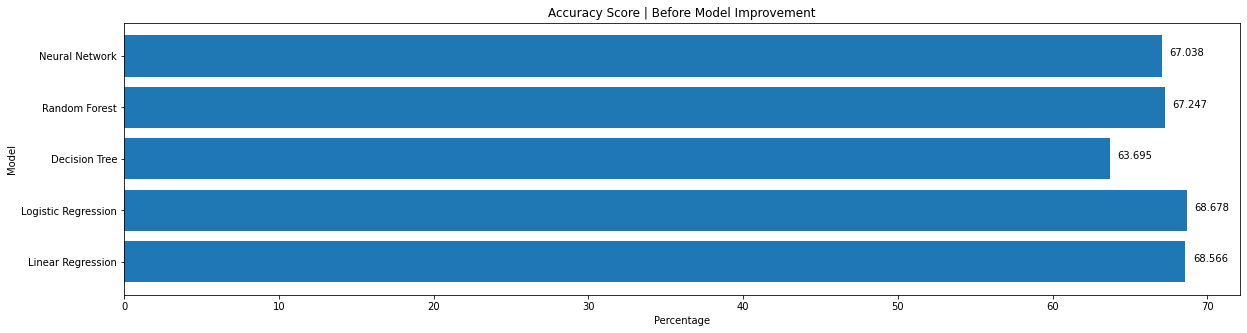

In [146]:
models = []
scores = []

for evaluationMetric in evaluationMetrics:
  models.append(evaluationMetric[0])
  scores.append(round(evaluationMetric[1] * 100, 3))

figScoreAccuracyBeforeImprov, axScoreAccuracyBeforeImprov = plt.subplots()

axScoreAccuracyBeforeImprov.barh(models, scores)

for i, v in enumerate(scores):
  axScoreAccuracyBeforeImprov.text(v + .5, i, str(v))

plt.title('Accuracy Score | Before Model Improvement')
plt.xlabel('Percentage')
plt.ylabel('Model')
plt.show()

<b>Logistic Regression has the highest accuracy score amongst the other 5 models - 68.678%</b>

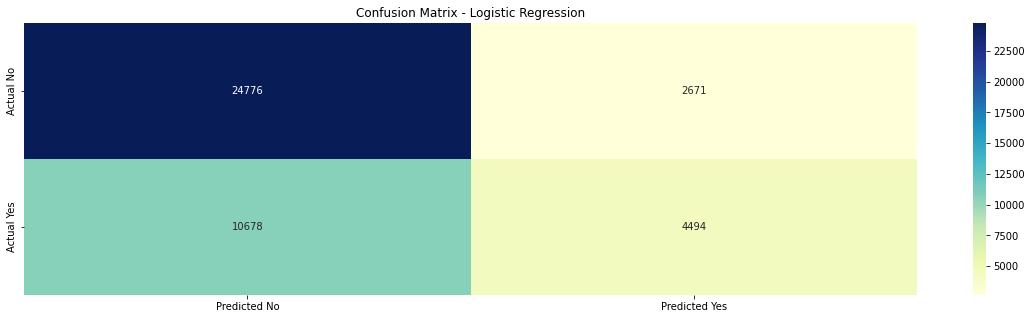

In [111]:
# Logistic Regression Y predictions
logRegPredY = []
for evaluationMetric in evaluationMetrics:
  if (evaluationMetric[0] == LABEL_LOGISTIC_REGRESSION):
    logRegPredY = evaluationMetric[-1]
printConfusionMatrix(y_validate, logRegPredY, 'Logistic Regression')

<h1> Model Improvement - Data Improvement</h1>
The best model amongst selected models with default configurations is Logistic Regression model with a 68.678% accuracy. </br>
Here we try to improve this percentage with changes to the feeding data.

In [112]:
dfPreprocessed['notify'].value_counts()

2    136972
1     76119
Name: notify, dtype: int64

The number of unnotified crimes (notify = 2) is almost twice the number of notified crimes (notify = 1)  
This might be leaning the model predictions more towards unnotified crimes  
To resolve this, we will 'oversample' rows with notify = 1 to make them equal in count with those with notify = 2 

In [113]:
dfPreprocessedAndSampled = pd.DataFrame()

# Append rows with notify = 2
dfPreprocessedAndSampled = dfPreprocessedAndSampled.append(dfPreprocessed[dfPreprocessed['notify'] == 2])

# Oversample rows with notify = 1
smpl = dfPreprocessed[dfPreprocessed['notify'] == 1]
smplToSize = 136972 # Number of rows with notify = 2
dfPreprocessedAndSampled = dfPreprocessedAndSampled.append(smpl.sample(smplToSize, random_state = RANDOM_STATE, replace = True))

C:\Users\uttej\AppData\Local\Temp\ipykernel_992\1532395319.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dfPreprocessedAndSampled = dfPreprocessedAndSampled.append(dfPreprocessed[dfPreprocessed['notify'] == 2])
C:\Users\uttej\AppData\Local\Temp\ipykernel_992\1532395319.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dfPreprocessedAndSampled = dfPreprocessedAndSampled.append(smpl.sample(smplToSize, random_state = RANDOM_STATE, replace = True))


In [115]:
dfPreprocessedAndSampled['notify'].value_counts()

2    136972
1    136972
Name: notify, dtype: int64

Now that there are equal number of rows for both classes of 'notify',  
encode the dataframe and run the model evaluation on it again

In [116]:
# Encode sampled data
dfSampledAndEncoded = pd.get_dummies(data = dfPreprocessedAndSampled, columns = [
  'year',
  'msa',
  'hincome',
  'hhage',
  'hhgen',
  'hhhisp',
  'hhrace1r',
  'hheth1r',
  'hnumber',
  'popsize',
  'region',
  'newoff',
  'vicservices',
  'locationr'
  ])

# Make notify column binary
dfSampledAndEncoded.notify.replace(2, 0, inplace=True) 

<h1> Model Evaluation - II </h1>
We run model evaluation with the sampled data here

In [182]:
dfPredictionOnSampled = dfSampledAndEncoded.copy()
Y_sample_data_improv = dfPredictionOnSampled['notify']
X_sample_data_improv = dfPredictionOnSampled.drop('notify', axis=1)

X_train_data_improv, X_validate_data_improv, y_train_data_improv, y_validate_data_improv = train_test_split(X_sample_data_improv, Y_sample_data_improv, test_size=0.2, random_state=RANDOM_STATE)

In [183]:
evaluationMetricsAfterDataImprov = getEvaluationMetrics(X_train_data_improv, X_validate_data_improv, y_train_data_improv, y_validate_data_improv, runClusteringAlgorithms = False)

c:\Users\uttej\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


<b> -------------------- NOTE -------------------- </b>  
Clustering algorithms are still not run at this point as the dimensionality of the input is too great

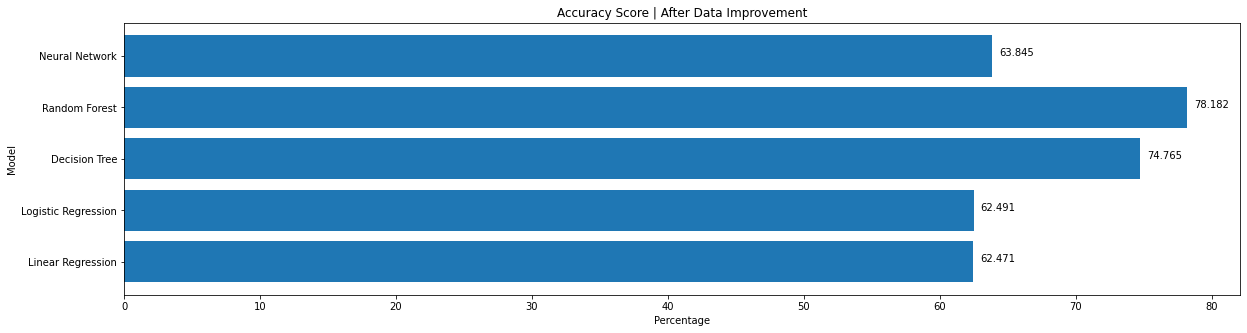

In [185]:
modelsAfterDataImprov = []
scoresAfterDataImprov = []

for evaluationMetric in evaluationMetricsAfterDataImprov:
  modelsAfterDataImprov.append(evaluationMetric[0])
  scoresAfterDataImprov.append(round(evaluationMetric[1] * 100, 3))

figScoreAccuracyAfterDataImprov, axScoreAccuracyAfterDataImprov = plt.subplots()

axScoreAccuracyAfterDataImprov.barh(modelsAfterDataImprov, scoresAfterDataImprov)

for i, v in enumerate(scoresAfterDataImprov):
  axScoreAccuracyAfterDataImprov.text(v + .5, i, str(v))

plt.title('Accuracy Score | After Data Improvement')
plt.xlabel('Percentage')
plt.ylabel('Model')
plt.show()

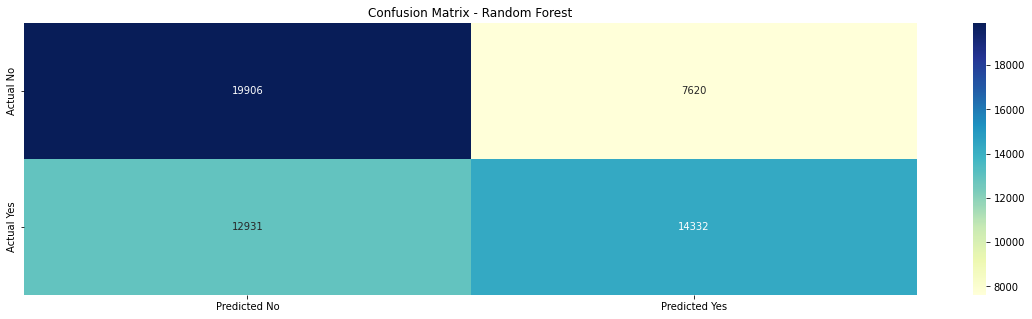

In [135]:
# Random Forest Y predictions
rfPredY = []
for evaluationMetric in evaluationMetricsAfterDataImprov:
  if (evaluationMetric[0] == LABEL_LOGISTIC_REGRESSION):
    rfPredY = evaluationMetric[-1]
printConfusionMatrix(y_validate_data_improv, rfPredY, LABEL_RANDOM_FOREST)

<b> With oversampling, Random Forest performed the best with an accuracy of 78.182% </b>

<h1> Model Evaluation - III </h1>
Here, we evaluate clustering algorithms

In [148]:
dfSampledAndEncoded.shape

(273944, 81)

<h3>Principal Component Analysis</h3>

Due to the high dimensionality (81 columns), clustering will not be very efficient.  
To prepare data for clustering models, we will perform PCA and reduce dimensions to 4 (chosen arbitrarily)

In [167]:
dfPCA = dfSampledAndEncoded.copy()

In [176]:
features = dfPCA.loc[:, dfPCA.columns != 'notify'].values
target = dfPCA.loc[:, ['notify']].values

pca = PCA(n_components = 4)

principalComponents = pca.fit_transform(features)
dfPrincipalComponents = pd.DataFrame(data = principalComponents)
dfPrincipalComponentsTarget = pd.DataFrame(data = target, columns = ['notify'])

dfPrincipalComponents.head()

,0,1,2,3
0,-0.651492,0.375195,-0.399749,0.399785
1,-0.651492,0.375195,-0.399749,0.399785
2,-0.651492,0.375195,-0.399749,0.399785
3,-0.295339,-0.714803,-0.027041,-0.124507
4,-0.904238,-0.359772,1.196762,-0.495250


In [177]:
dfPrincipalComponentsFinal = pd.concat([dfPrincipalComponents, dfPrincipalComponentsTarget], axis = 1)
dfPrincipalComponentsFinal.head()

,0,1,2,3,notify
0,-0.651492,0.375195,-0.399749,0.399785,0
1,-0.651492,0.375195,-0.399749,0.399785,0
2,-0.651492,0.375195,-0.399749,0.399785,0
3,-0.295339,-0.714803,-0.027041,-0.124507,0
4,-0.904238,-0.359772,1.196762,-0.495250,0


In [186]:
dfPredictionOnPrincipalComponents = dfPrincipalComponentsFinal.copy()
Y_sample_pc = dfPredictionOnPrincipalComponents['notify']
X_sample_pc = dfPredictionOnPrincipalComponents.drop('notify', axis=1)

X_train_pc, X_validate_pc, y_train_pc, y_validate_pc = train_test_split(X_sample_pc, Y_sample_pc, test_size=0.2, random_state=RANDOM_STATE)

In [189]:
clusteringEvalMetrics = []

LABEL_KNN = 'K Nearest Neighbours'
clusteringEvalMetrics.append(modelKNN(X_train, X_validate, y_train, y_validate, LABEL_KNN))

LABEL_K_MEANS = 'K Means'
clusteringEvalMetrics.append(modelKMeans(X_train, X_validate, y_train, y_validate, LABEL_K_MEANS))

In [190]:
clusteringEvalMetrics

[('K Nearest Neighbours',
  0.6965631787402581,
  0.7594908850823461,
  0.6728407096899981,
  0.7135448076227233,
  array([1, 0, 0, ..., 0, 0, 1], dtype=int64)),
 ('K Means',
  0.6379930277975506,
  0.5365880497377398,
  0.6701635439094782,
  0.595983052228469,
  array([1, 0, 1, ..., 0, 0, 0], dtype=int64))]